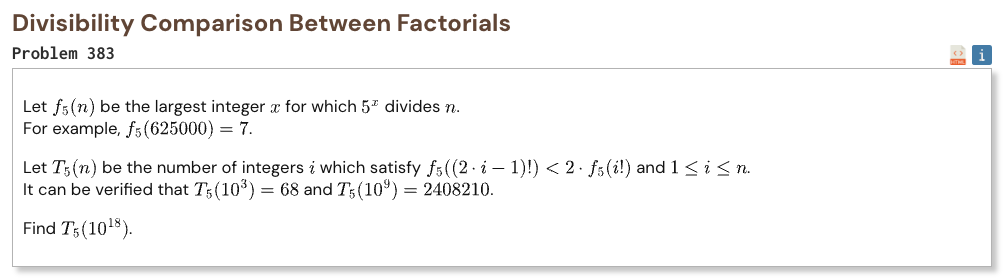

## Initial approach

* use legendre’s formula to replace factorial divisibility with base five digit sums
* the condition becomes a comparison between the digit sums of i and 2i - 1
* process the base five digits from right to left so multiplication by two and subtraction by one are easy
* keep the carry produced while calculating the digits of 2i - 1
* track the difference between the digit sum of 2i - 1 and twice the digit sum of i
* also track whether the current number is smaller than or equal to the given limit
* use digit dp because 10^18 has only 26 digits in base five
* count states whose final digit sum difference is nonnegative

In [1]:
from collections import defaultdict


def to_base_five(n):
    digits = []

    while n > 0:
        digits.append(n % 5)
        n //= 5

    return digits


def solve(limit):
    limit_digits = to_base_five(limit)

    dp = {
        (-1, 0, 0, False): 1
    }

    for limit_digit in limit_digits:
        new_dp = defaultdict(int)

        for state, count in dp.items():
            carry, relation, difference, nonzero = state

            for digit in range(5):
                value = 2 * digit + carry
                output_digit = value % 5
                next_carry = value // 5

                if digit < limit_digit:
                    next_relation = -1
                elif digit > limit_digit:
                    next_relation = 1
                else:
                    next_relation = relation

                next_difference = difference + output_digit - 2 * digit
                next_nonzero = nonzero or digit != 0

                next_state = (
                    next_carry,
                    next_relation,
                    next_difference,
                    next_nonzero
                )

                new_dp[next_state] += count

        dp = new_dp

    result = 0

    for state, count in dp.items():
        carry, relation, difference, nonzero = state

        if nonzero and relation <= 0 and difference + carry >= 0:
            result += count

    return result


assert solve(10**3) == 68
assert solve(10**9) == 2_408_210

In [2]:
%%time
result = solve(10**18)
print("Result:", result)

Result: 22173624649806
CPU times: user 3.21 ms, sys: 149 μs, total: 3.36 ms
Wall time: 3.47 ms
